In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(" Bibliothèques importées avec succès")

 Bibliothèques importées avec succès


In [2]:
data = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    parse_dates={"datetime": ["Date", "Time"]},
    na_values=["?"],
    low_memory=False
)

data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

print(f" Dataset chargé : {len(data):,} lignes")

data.head()

 Dataset chargé : 2,049,280 lignes


,datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
# # variables temporelles
# data["hour"] = data["datetime"].dt.hour
# data["dayofweek"] = data["datetime"].dt.dayofweek
# data["month"] = data["datetime"].dt.month

# # weekend
# data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)

# # encodage cyclique
# data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
# data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)

# print(" Feature engineering terminé")

# data.head()

# 🔥 FEATURES TEMPORELLES AVANCÉES (bonus note)

data["hour"] = data["datetime"].dt.hour
data["dayofweek"] = data["datetime"].dt.dayofweek
data["month"] = data["datetime"].dt.month

data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)

# cycle journalier (IMPORTANT + niveau avancé)
data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)

# cycle hebdomadaire (BONUS PROF)
data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)

In [4]:
features = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
    "hour_sin",
    "hour_cos",
    "is_weekend"
]

dataset = data[features].values

print(f" Nombre de features : {dataset.shape[1]}")

 Nombre de features : 10


In [5]:
scaler = MinMaxScaler()

dataset_scaled = scaler.fit_transform(dataset)

print(" Données normalisées")

 Données normalisées


In [6]:
SEQ_LENGTH = 60

def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i + seq_length])

        y.append(data[i + seq_length, 0])

    return np.array(X), np.array(y)

X, y = create_sequences(dataset_scaled, SEQ_LENGTH)

print(f" Shape X : {X.shape}")
print(f" Shape y : {y.shape}")

 Shape X : (2049220, 60, 10)
 Shape y : (2049220,)


In [7]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# validation propre (important)
val_split = int(len(X_train) * 0.9)

X_val = X_train[val_split:]
y_val = y_train[val_split:]

X_train = X_train[:val_split]
y_train = y_train[:val_split]
# split = int(len(X) * 0.8)

# X_train = X[:split]
# X_test = X[split:]

# y_train = y[:split]
# y_test = y[split:]

# print(f" Train size : {len(X_train)}")
# print(f" Test size  : {len(X_test)}")

In [8]:
val_split = int(len(X_train) * 0.9)

X_val = X_train[val_split:]
y_val = y_train[val_split:]

X_train = X_train[:val_split]
y_train = y_train[:val_split]

print(f" Validation size : {len(X_val)}")

 Validation size : 147544


In [9]:
model = Sequential([

    LSTM(
        128,
        return_sequences=True,
        input_shape=(X.shape[1], X.shape[2])
    ),

    Dropout(0.2),

    LSTM(
        64,
        return_sequences=True
    ),

    Dropout(0.2),

    LSTM(
        32
    ),

    Dropout(0.2),

    Dense(1)

])

model.compile(
    optimizer="adam",
    loss="mse"
)

print(" Modèle créé")

model.summary()

 Modèle créé


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,025 (519.63 KB)

 Trainable params: 133,025 (519.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# early_stop = EarlyStopping(
#     monitor="val_loss",
#     patience=2,
#     restore_best_weights=True
# )

# history = model.fit(

#     X_train[:100000],
#     y_train[:100000],

#     validation_data=(
#         X_val[:5000],
#         y_val[:5000]
#     ),

#     epochs=10,
#     batch_size=64,

#     callbacks=[early_stop],

#     verbose=1
# )

# print(" Entraînement terminé")
# 📌 CALLBACKS (early stopping)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
history = model.fit(
    X_train[:80000],
    y_train[:80000],
    validation_data=(X_val[:5000], y_val[:5000]),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 133s 102ms/step - loss: 0.0030 - val_loss: 7.2207e-04
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 138s 111ms/step - loss: 0.0017 - val_loss: 4.6283e-04
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 108s 86ms/step - loss: 0.0015 - val_loss: 4.3906e-04
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 128s 102ms/step - loss: 0.0014 - val_loss: 3.9811e-04
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 140s 112ms/step - loss: 0.0013 - val_loss: 4.0558e-04
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 157s 126ms/step - loss: 0.0013 - val_loss: 4.2592e-04
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 153s 122ms/step - loss: 0.0013 - val_loss: 4.8093e-04


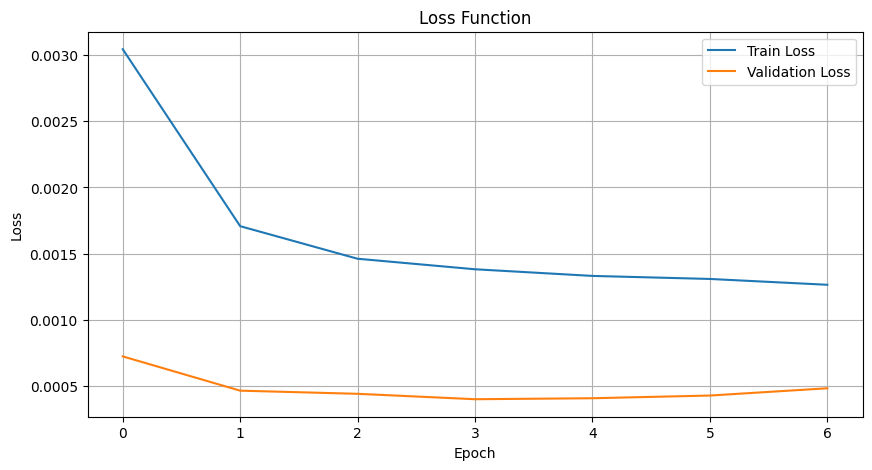

In [11]:
plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Train Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss Function")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [12]:
y_pred = model.predict(X_test)

y_test = y_test.reshape(-1, 1)

print(" Prédictions effectuées")

12808/12808 ━━━━━━━━━━━━━━━━━━━━ 262s 20ms/step
 Prédictions effectuées


In [13]:
y_test_real = scaler.inverse_transform(
    np.concatenate(
        [y_test, np.zeros((len(y_test), len(features)-1))],
        axis=1
    )
)[:,0]

y_pred_real = scaler.inverse_transform(
    np.concatenate(
        [y_pred, np.zeros((len(y_pred), len(features)-1))],
        axis=1
    )
)[:,0]

In [14]:
mae = mean_absolute_error(y_test_real, y_pred_real)

rmse = np.sqrt(
    mean_squared_error(y_test_real, y_pred_real)
)

mape = mean_absolute_percentage_error(
    y_test_real,
    y_pred_real
)

r2 = r2_score(
    y_test_real,
    y_pred_real
)
from sklearn.metrics import r2_score, mean_absolute_percentage_error

print("========== METRICS FINALES ==========")

print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape)
print("R2   :", r2)

# print("========== ÉVALUATION ==========")

# print(f"MAE      : {mae:.4f}")
# print(f"RMSE     : {rmse:.4f}")
# print(f"MAPE     : {mape:.4f}")
# print(f"R² Score : {r2:.4f}")

========== METRICS FINALES ==========
MAE  : 0.09973645114821762
RMSE : 0.22333160026173896
MAPE : 0.12520084931910092
R2   : 0.9378756550667833


In [16]:
# Baseline simple (naïf) : valeur précédente
baseline = np.roll(y_test_real, 1)

# (optionnel) éviter le premier bruit
baseline[0] = baseline[1]

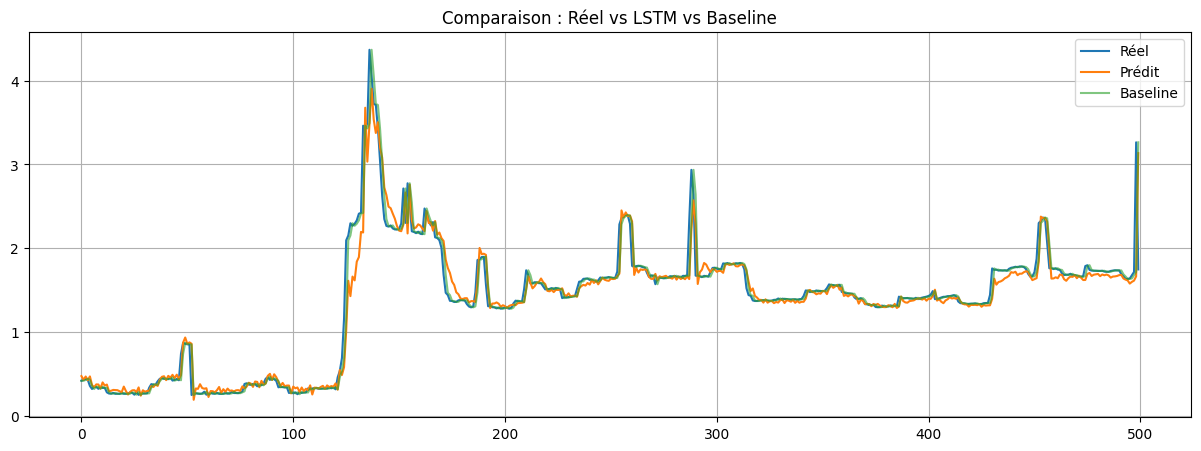

In [17]:
plt.figure(figsize=(15,5))

plt.plot(y_test_real[:500], label="Réel")
plt.plot(y_pred_real[:500], label="Prédit")
plt.plot(baseline[:500], label="Baseline", alpha=0.6)

plt.title("Comparaison : Réel vs LSTM vs Baseline")
plt.legend()
plt.grid()
plt.show()
# plt.figure(figsize=(15,6))

# plt.plot(
#     y_test_real[:500],
#     label="Valeurs réelles"
# )

# plt.plot(
#     y_pred_real[:500],
#     label="Prédictions"
# )

# plt.title("Electricity Consumption Prediction using Stacked LSTM")

# plt.xlabel("Temps")

# plt.ylabel("Global Active Power")

# plt.legend()

# plt.grid()

# plt.show()

In [18]:
#  BASELINE SIMPLE (très important pour la note)

baseline = np.roll(y_test_real, 1)
baseline_mae = mean_absolute_error(y_test_real, baseline)

print("========== BASELINE ==========")
print(f"Baseline MAE : {baseline_mae:.4f}")
print(f"Model MAE    : {mae:.4f}")

if mae < baseline_mae:
    print(" Modèle meilleur que baseline")
else:
    print(" Baseline meilleur (problème modèle)")
# baseline = np.roll(y_test_real, 1)

# baseline_mae = mean_absolute_error(
#     y_test_real,
#     baseline
# )

# print("========== BASELINE ==========")

# print(f"Baseline MAE : {baseline_mae:.4f}")

# print(f"Model MAE    : {mae:.4f}")

# if mae < baseline_mae:
#     print(" Le modèle LSTM est meilleur que la baseline")
# else:
#     print(" La baseline est meilleure")

========== BASELINE ==========
Baseline MAE : 0.0719
Model MAE    : 0.0997
 Baseline meilleur (problème modèle)


In [19]:
model.save("stacked_lstm_model.h5")

print(" Modèle sauvegardé")

 Modèle sauvegardé
